In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from collections import Counter
from tensorflow.keras.datasets import cifar10, cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import random

In [ ]:
np.random.seed(42)
random.seed(42)

In [ ]:
print ("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Load CIFAR -10

In [ ]:
(x10_train, y10_train), (x10_test, y10_test) = cifar10.load_data()

print("CIFAR-10")
print(f"Training Images: {x10_train.shape[0]}")
print(f"Training Labels: {y10_train.shape[0]}")
print(f"Test Images: {x10_test.shape[0]}")
print(f"Test Labels: {y10_test.shape[0]}")

CIFAR-10
Training Images: 50000
Training Labels: 50000
Test Images: 10000
Test Labels: 10000


# Load CIFAR - 100

In [ ]:
(x100_train, y100_train), (x100_test, y100_test) = cifar100.load_data()

print("\nCIFAR-100")
print(f"Training Images: {x100_train.shape[0]}")
print(f"Training Labels: {y100_train.shape[0]}")
print(f"Test Images: {x100_test.shape[0]}")
print(f"Test Labels: {y100_test.shape[0]}")


CIFAR-100
Training Images: 50000
Training Labels: 50000
Test Images: 10000
Test Labels: 10000


# CIFAR - 10 Classes

In [ ]:
cifar10_classes = ['airplane', 
                   'automobile', 
                    'bird', 
                    'cat', 
                    'deer', 
                    'dog', 
                    'frog', 
                    'horse', 
                    'ship', 
                    'truck']

required_classes = ['automobile', 'bird', 'cat', 'deer', 'dog', 'horse','truck']

In [ ]:
print("CIFAR-10 selected labels:")
print(np.unique(y10_train_selected))

CIFAR-10 selected labels:
[0 1 2 3 4 5 6]


# CIFAR - 100 Classes

In [ ]:
cifar100_classes = [
    "apple","aquarium_fish","baby","bear","beaver","bed","bee","beetle",
    "bicycle","bottle","bowl","boy","bridge","bus","butterfly","camel",
    "can","castle","caterpillar","cattle","chair","chimpanzee","clock",
    "cloud","cockroach","couch","crab","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox","girl","hamster",
    "house","kangaroo","keyboard","lamp","lawn_mower","leopard","lion",
    "lizard","lobster","man","maple_tree","motorcycle","mountain","mouse",
    "mushroom","oak_tree","orange","orchid","otter","palm_tree","pear",
    "pickup_truck","pine_tree","plain","plate","poppy","porcupine",
    "possum","rabbit","raccoon","ray","road","rocket","rose","sea",
    "seal","shark","shrew","skunk","skyscraper","snail","snake",
    "spider","squirrel","streetcar","sunflower","sweet_pepper","table",
    "tank","telephone","television","tiger","tractor","train","trout",
    "tulip","turtle","wardrobe","whale","willow_tree","wolf","woman",
    "worm"
]

required_cifar100 = [
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor"
]

# Tree categories to combine into one class
tree_classes = [
    "maple_tree",
    "oak_tree",
    "palm_tree",
    "pine_tree",
    "willow_tree"
]

In [ ]:
print(x100_train.shape)
print(y100_train.shape)

(50000, 32, 32, 3)
(50000,)


In [ ]:
print(extract_cifar100_classes)

<function extract_cifar100_classes at 0x000001AE50486C00>


# Final Classes

In [ ]:
final_classes = ["automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "trees",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor"]

In [ ]:
final_class_to_label = {class_name: label for label, class_name in enumerate(final_classes)}

print("Number of final classes:", len(final_classes))
print("\nFinal label mapping:")
for class_name, label in final_class_to_label.items():
    print(f"  {label:2d}: {class_name}")

Number of final classes: 24

Final label mapping:
   0: automobile
   1: bird
   2: cat
   3: deer
   4: dog
   5: horse
   6: truck
   7: cattle
   8: fox
   9: baby
  10: boy
  11: girl
  12: man
  13: woman
  14: rabbit
  15: squirrel
  16: trees
  17: bicycle
  18: bus
  19: motorcycle
  20: pickup_truck
  21: train
  22: lawn_mower
  23: tractor


In [ ]:
y10_train = y10_train.flatten() 
y10_test = y10_test.flatten()

y100_train = y100_train.flatten()
y100_test = y100_test.flatten()

print("CIFAR-10 training labels shape:", y10_train.shape)

print("CIFAR-100 training labels shape:", y100_train.shape)


CIFAR-10 training labels shape: (50000,)
CIFAR-100 training labels shape: (50000,)


In [ ]:
def extract_cifar100_classes(images, labels):

    selected_images = []
    selected_labels = []

    for class_name in required_cifar100:
        original_label = cifar100_classes.index(class_name)

        class_mask = labels == original_label
        class_images = images[class_mask]

        new_label = final_class_to_label[class_name]

        class_labels = np.full(
            len(class_images),
            new_label,
            dtype=np.int32
        )

        selected_images.append(class_images)
        selected_labels.append(class_labels)

    tree_original_labels = [
        cifar100_classes.index(tree_name)
        for tree_name in tree_classes
    ]

    tree_mask = np.isin(labels, tree_original_labels)
    tree_images = images[tree_mask]

    tree_label = final_class_to_label["trees"]

    tree_labels = np.full(
        len(tree_images),
        tree_label,
        dtype=np.int32
    )

    selected_images.append(tree_images)
    selected_labels.append(tree_labels)

    selected_images = np.concatenate(selected_images, axis=0)
    selected_labels = np.concatenate(selected_labels, axis=0)

    return selected_images, selected_labels

In [ ]:
x100_train_selected, y100_train_selected = extract_cifar100_classes(
    x100_train,
    y100_train
)

x100_test_selected, y100_test_selected = extract_cifar100_classes(
    x100_test,
    y100_test
)

print("Selected CIFAR-100 training images:", x100_train_selected.shape)
print("Selected CIFAR-100 training labels:", y100_train_selected.shape)

print("Selected CIFAR-100 test images:", x100_test_selected.shape)
print("Selected CIFAR-100 test labels:", y100_test_selected.shape)

print("\nSelected CIFAR-100 labels:")
print(np.unique(y100_train_selected))

Selected CIFAR-100 training images: (10500, 32, 32, 3)
Selected CIFAR-100 training labels: (10500,)
Selected CIFAR-100 test images: (2100, 32, 32, 3)
Selected CIFAR-100 test labels: (2100,)

Selected CIFAR-100 labels:
[ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


# Merge the selected datasets

In [ ]:
x_train_combined = np.concatenate((x10_train_selected, x100_train_selected),axis=0)

y_train_combined = np.concatenate((y10_train_selected, y100_train_selected),axis=0)

x_test_combined = np.concatenate((x10_test_selected, x100_test_selected),axis=0)

y_test_combined = np.concatenate((y10_test_selected, y100_test_selected),axis=0)

print("Datasets merged successfully!\n")

print("Training Images :", x_train_combined.shape)
print("Training Labels :", y_train_combined.shape)

print("Test Images     :", x_test_combined.shape)
print("Test Labels     :", y_test_combined.shape)

Datasets merged successfully!

Training Images : (45500, 32, 32, 3)
Training Labels : (45500,)
Test Images     : (9100, 32, 32, 3)
Test Labels     : (9100,)


In [ ]:
rng = np.random.default_rng(seed=42)

train_indices = rng.permutation(len(x_train_combined))

x_train_combined = x_train_combined[train_indices]
y_train_combined = y_train_combined[train_indices]

test_indices = rng.permutation(len(x_test_combined))

x_test_combined = x_test_combined[test_indices]
y_test_combined = y_test_combined[test_indices]

print("Datasets shuffled successfully!")

Datasets shuffled successfully!


In [ ]:
print("Training images:", x_train_combined.shape)
print("Training labels:", y_train_combined.shape)

print("\nTest images:", x_test_combined.shape)
print("Test labels:", y_test_combined.shape)

unique_labels = np.unique(y_train_combined)

print("\nUnique labels:")
print(unique_labels)

print("\nNumber of classes:", len(unique_labels))

assert np.array_equal(unique_labels, np.arange(24)), \
    "Error: Labels should be numbered from 0 to 23."

print("\nDataset verification successful!")


Training images: (45500, 32, 32, 3)
Training labels: (45500,)

Test images: (9100, 32, 32, 3)
Test labels: (9100,)

Unique labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Number of classes: 24

Dataset verification successful!


### Normalizing images

In [ ]:
x_train_combined = x_train_combined.astype("float32") / 255.0
x_test_combined = x_test_combined.astype("float32") / 255.0

print("Pixel range:")
print("Minimum:", x_train_combined.min())
print("Maximum:", x_train_combined.max())

Pixel range:
Minimum: 0.0
Maximum: 1.0


In [ ]:
num_classes = len(final_classes)

y_train_encoded = to_categorical(
    y_train_combined,
    num_classes=num_classes
)

y_test_encoded = to_categorical(
    y_test_combined,
    num_classes=num_classes
)

print(y_train_encoded.shape)
print(y_test_encoded.shape)

(45500, 24)
(9100, 24)


### Training and validation sets

In [ ]:
x_train, x_validation, y_train, y_validation = train_test_split(
    x_train_combined,
    y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_combined
)

print("Training:", x_train.shape)
print("Validation:", x_validation.shape)
print("Test:", x_test_combined.shape)

Training: (36400, 32, 32, 3)
Validation: (9100, 32, 32, 3)
Test: (9100, 32, 32, 3)


In [ ]:
print(x10_train_selected.shape)
print(x100_train_selected.shape)

(35000, 32, 32, 3)
(10500, 32, 32, 3)


# Exploring the Combined Dataset

In [ ]:
print("Training images shape:", x_train_combined.shape)
print("Training labels shape:", y_train_combined.shape)

print("Test images shape:", x_test_combined.shape)
print("Test labels shape:", y_test_combined.shape)

print("Number of classes:", len(final_classes))

Training images shape: (85000, 32, 32, 3)
Training labels shape: (85000,)
Test images shape: (17000, 32, 32, 3)
Test labels shape: (17000,)
Number of classes: 24


In [ ]:
train_class_counts = Counter(y_train_combined)
test_class_counts = Counter(y_test_combined)

print("Training set class distribution:\n")

for label, class_name in enumerate(final_classes):
    print(
        f"{label:2d} - {class_name:15s}: "
        f"{train_class_counts[label]} training images"
        f"{test_class_counts[label]} test images"
    )

Training set class distribution:

 0 - automobile     : 5500 training images1100 test images
 1 - bird           : 5500 training images1100 test images
 2 - cat            : 5500 training images1100 test images
 3 - deer           : 5500 training images1100 test images
 4 - dog            : 5500 training images1100 test images
 5 - horse          : 5500 training images1100 test images
 6 - truck          : 5500 training images1100 test images
 7 - cattle         : 500 training images100 test images
 8 - fox            : 500 training images100 test images
 9 - baby           : 500 training images100 test images
10 - boy            : 500 training images100 test images
11 - girl           : 500 training images100 test images
12 - man            : 500 training images100 test images
13 - woman          : 500 training images100 test images
14 - rabbit         : 500 training images100 test images
15 - squirrel       : 500 training images100 test images
16 - trees          : 500 training image

## Class Distribution Chart

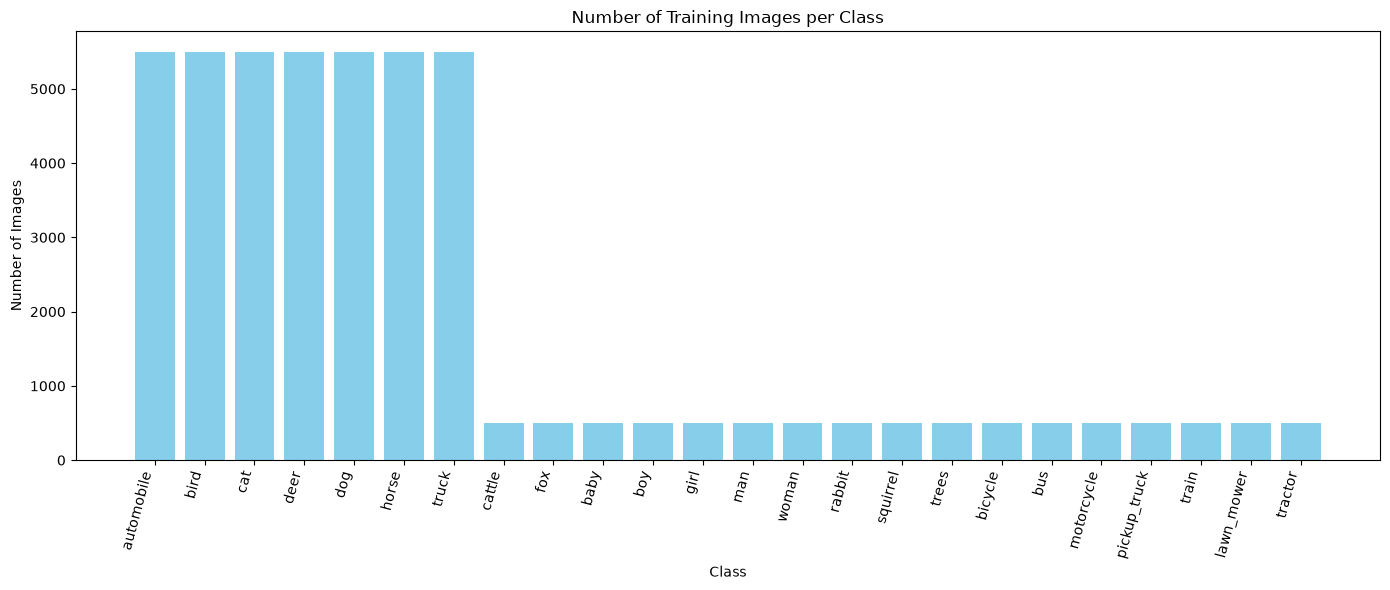

In [ ]:
class_labels = np.arange(len(final_classes))

training_counts = [
    train_class_counts[label] for label in class_labels
]

plt.figure(figsize=(14, 6))

plt.bar(class_labels, training_counts, color='skyblue')

plt.xticks(class_labels, final_classes, rotation=75, ha='right')

plt.title("Number of Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

## Displaying one image from each class

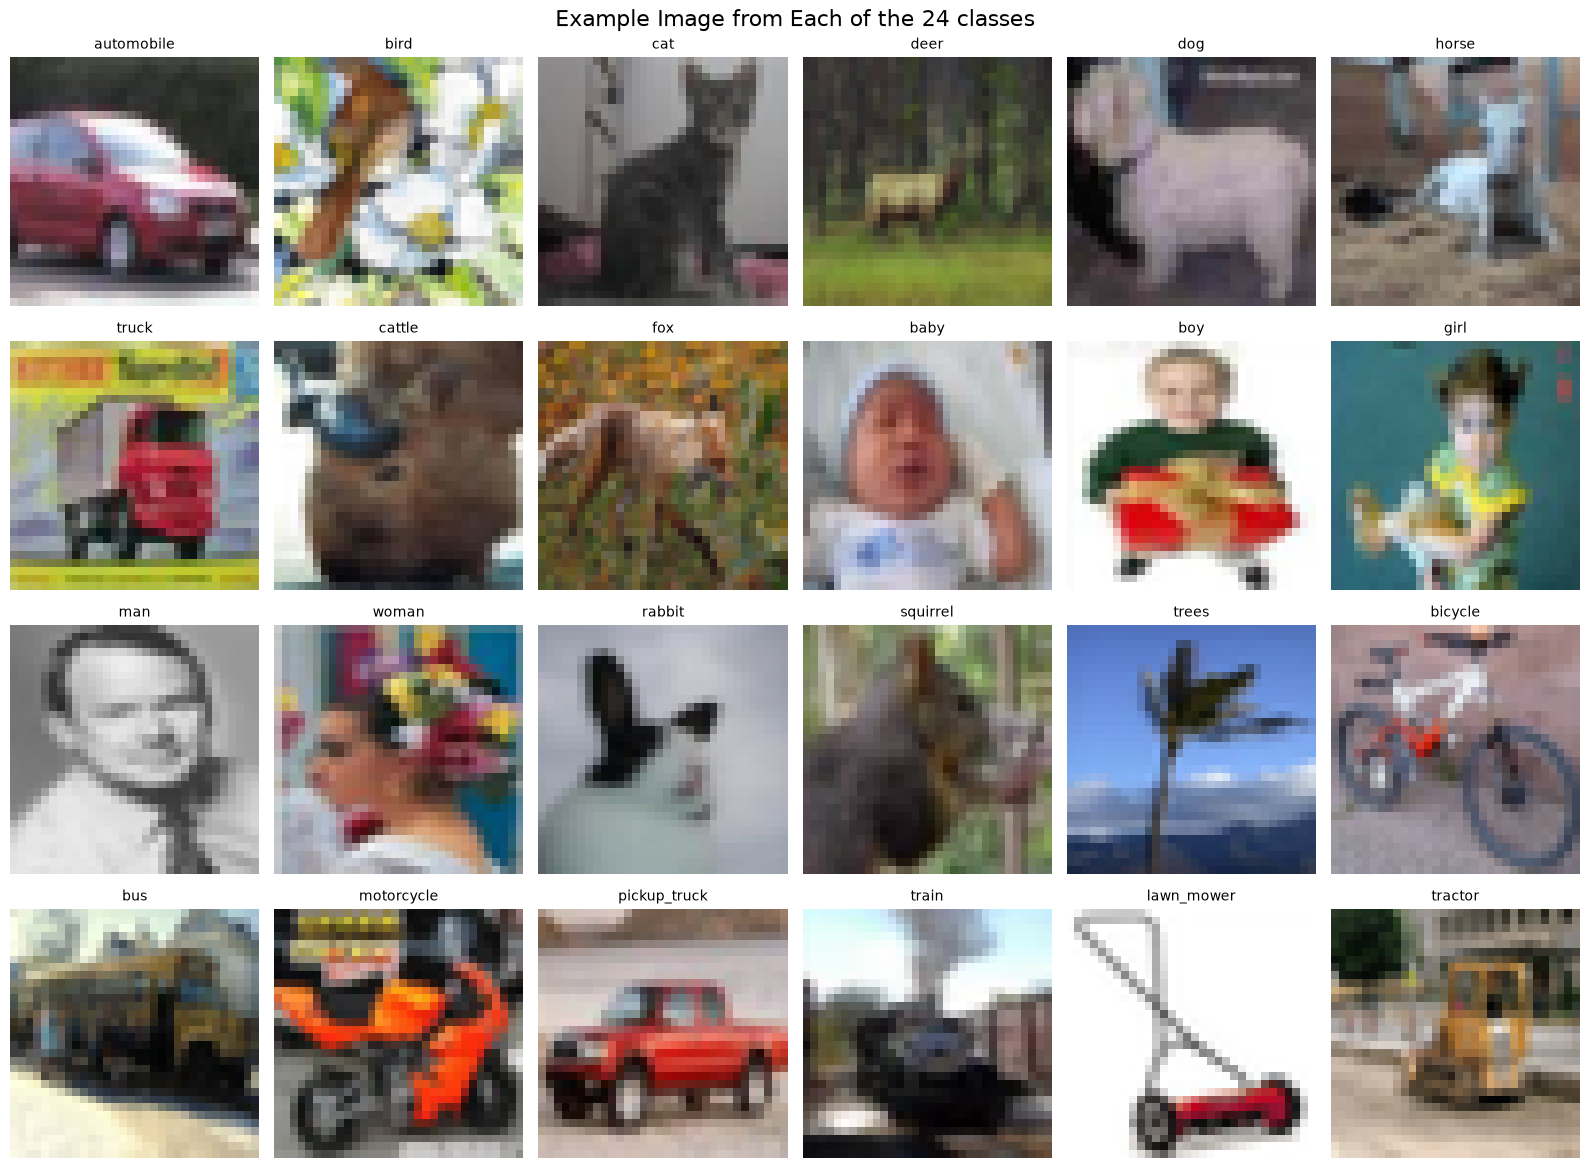

In [ ]:
plt.figure(figsize=(16, 12))

for label, class_name in enumerate(final_classes):
    class_indices = np.where(y_train_combined == label)[0]
    random_index = np.random.choice(class_indices)
    image = x_train_combined[random_index]

    plt.subplot(4, 6, label + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=10)
    plt.axis('off')

plt.suptitle("Example Image from Each of the 24 classes", fontsize=16)

plt.tight_layout()
plt.show()

## Inspecting image information

In [ ]:
sample_image = x_train_combined[0]

print("Sample image shape:", sample_image.shape)
print("Image data type:", sample_image.dtype)
print("Minimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())

Sample image shape: (32, 32, 3)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 254


## Are all classes present?

In [ ]:
unique_labels = np.unique(y_train_combined)

print("Unique labels in the combined training set:", unique_labels)
print("Number of unique labels in the combined training set:", len(unique_labels))

assert len(unique_labels) == len(final_classes), "Mismatch between unique labels and final classes"
assert len(unique_labels) == 24, "The dataset does not contain 24 classes."

print("All checks passed. The combined dataset contains 24 unique classes as expected.")

Unique labels in the combined training set: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Number of unique labels in the combined training set: 24
All checks passed. The combined dataset contains 24 unique classes as expected.


In [ ]:
np.save("x_train.npy", x_train)
np.save("y_train.npy", y_train)

np.save("x_validation.npy", x_validation)
np.save("y_validation.npy", y_validation)

np.save("x_test.npy", x_test_combined)
np.save("y_test.npy", y_test_combined)